<a href="https://colab.research.google.com/github/khanhnk2010/ML2-Product-Recommendation-/blob/main/Extra_Tree_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc #để xoá object khỏi ram khi không cần nữa

from google.colab import drive
#drive ngáo lắm phải forece_remount
drive.mount("/content/drive", force_remount=True)
import shutil
import os
import pyarrow.parquet as pq
import pyarrow as pa
import joblib
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import time
from sklearn.utils import resample

pd.set_option('display.max_columns', None)
if hasattr(pd, 'options'):
    pd.options.mode.copy_on_write = True  #chỉ tạo copy của dataframe khi có hành động write->kiểm soát số lượng copy

Mounted at /content/drive


In [ ]:
cwd = '/content/drive/MyDrive/bank_data/'

In [ ]:
start = time.time()
!cp -r /content/drive/MyDrive/bank_data/ /content/
print(time.time() - start)
cwd = '/content/bank_data/'

166.75440907478333


In [ ]:
target = ["product_1","product_2",
              "product_3","product_4","product_5",
               "product_6","product_7","product_8","product_9","product_10","product_11",
               "product_12","product_13","product_14","product_15","product_16",
               "product_17","product_18","product_19","product_20","product_21",
               "product_22","product_23","product_24"]

In [ ]:
customer_info_cols = ['customer_code', 'employee_index', 'customer_country', 'sex', 'age',
       'new_index', 'seniority_months', 'primary_customer', 'month_start_type',
       'relation_type', 'residence_index', 'foreigner_index', 'join_channel',
       'province_code', 'activity_index', 'gross_househole_income', 'segment']

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_recall_curve, confusion_matrix, classification_report

binary_valid_parquet = cwd+"binary_valid.parquet"
binary_train_parquet = cwd+"binary_train.parquet"

df_train = pd.read_parquet(binary_train_parquet)
n_rows_merged = 183288456
n_1_merged = 309212
scale_pos_weight = (n_rows_merged - n_1_merged) / n_1_merged
scaling_cols = ['age', 'seniority_months', 'gross_househole_income']
nominal_cols = ['employee_index', 'relation_type', 'month_start_type', 'product']
nominal_categories = {}
ordinal_col = 'segment'
label_map = {'01 - TOP': 3, '02 - PARTICULARES': 2, '03 - UNIVERSITARIO': 1}
cat_encoder = ColumnTransformer(
    transformers = [('categorical_encoder', OneHotEncoder(), nominal_cols)],
    remainder = 'passthrough'
)
cat_encoder.fit(df_train)
n_features = len(cat_encoder.get_feature_names_out())
print(n_features)
len_dtrain = len(df_train)
print(len_dtrain)
cat_prefix = 'categorical_encoder__'
non_cat_prefix = 'remainder__'
del df_train
gc.collect()

66
3440182


23

In [ ]:
def generate_dtrain(binary_train_parquet):
  df_train = pd.read_parquet(binary_train_parquet)
  df_train['gross_househole_income'] = np.log1p(df_train['gross_househole_income'])
  df_train[ordinal_col] = df_train[ordinal_col].map(label_map)
  df_train[ordinal_col] = df_train[ordinal_col].fillna(df_train[ordinal_col].mode()[0]).astype(np.int8)
  df_train = cat_encoder.transform(df_train)
  df_train = pd.DataFrame(data=df_train, columns=cat_encoder.get_feature_names_out())
  df_train.drop(columns=[non_cat_prefix+'customer_code'], inplace=True)
  X_train = df_train.drop(columns=[non_cat_prefix+'new_buy'])
  y_train = df_train[non_cat_prefix+'new_buy']
  del df_train
  gc.collect()
  return X_train, y_train

In [ ]:
from sklearn.model_selection import StratifiedKFold
target_cols = [f'{product}_last_0' for product in target]
categorical_cols = ['employee_index', 'relation_type', 'segment']
high_cardinal_cols = ['province_code', 'join_channel', 'customer_country']
int8_cols = ['age', 'activity_index', 'new_index']
int16_cols = ['seniority_months']
to_binary_cols = ['sex', 'primary_customer', 'residence_index', 'foreigner_index']
dtype_dict = {'customer_code': np.int32,
              'product': np.int8,
              'new_buy': np.int8,
              'month_start_type': 'string',
              **{col: 'category' for col in categorical_cols},
              **{col: np.float32 for col in high_cardinal_cols+['month_sin','month_cos']},
              **{col: np.int8 for col in int8_cols+to_binary_cols},
              'seniority_months': np.int16,
              **{f'product'+f'_last_{month}': np.int8 for month in list(range(6,0,-1))},
              **{f'product'+f'_diff_last_{month}': np.int8 for month in list(range(5,0,-1))}
              }
nominal_cols = ['employee_index', 'relation_type', 'month_start_type', 'product']

def generate_dval(val_parquet, n_splits, min_per_fold, dataset, batch_size=30000):
  if os.path.exists(dataset):
    shutil.rmtree(dataset)
  os.mkdir(dataset)
  df = pd.read_parquet(val_parquet)
  df['total_new_buy'] = df[target_cols].sum(axis=1)
  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=None)
  fold = np.random.choice(range(0, n_splits))
  counts = df['total_new_buy'].value_counts()
  minimum = n_splits * min_per_fold
  minimum_list = []
  for total, n_customer in counts.items():
    if n_customer < minimum:
      minimum_list.append(df[df["total_new_buy"]==total].copy())
      df = df[df['total_new_buy'] != total]
  for i, (train_index, test_index) in enumerate(skf.split(df.drop(columns=['total_new_buy']), df['total_new_buy'])):
    if i != fold:
      continue
    df_fold = df.iloc[test_index]
    break
  df_fold.drop(columns=['total_new_buy'], inplace=True)
  del df
  gc.collect()
  n_row = len(df_fold)
  n_batch = n_row // batch_size + 1
  start = 0
  end = 0
  for batch in range(n_batch):
    df_list = []
    start += batch * batch_size
    end = start + batch_size
    if end >= n_row:
      end = n_row - 1
    df_batch = df_fold.iloc[start:end]
    for label, product in enumerate(target_cols):
      product_df = df_batch.copy()
      product_df['product'] = label+1
      product_df['new_buy'] = product_df[product]
      cols = (['customer_code', 'product', 'new_buy']+
              customer_info_cols[1:]+['month_sin', 'month_cos']+
              [f'product_{label+1}'+f'_last_{month}' for month in list(range(6,0,-1))]+
              [f'product_{label+1}'+f'_diff_last_{month}' for month in list(range(5,0,-1))])
      product_df = product_df[cols]
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_last_{month}':'product'+f'_last_{month}' for month in list(range(6,0,-1))})
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_diff_last_{month}':'product'+f'_diff_last_{month}' for month in list(range(5,0,-1))})
      df_list.append(product_df)
    df_product = pd.concat(df_list, ignore_index=True)
    table = pa.Table.from_pandas(df_product)
    for df in df_list:
      del df
      gc.collect()
    del df_batch, df_product
    gc.collect()
    pq.write_to_dataset(table, root_path=dataset)
    del table
    gc.collect()
  del df_fold
  gc.collect()
  df_val = pd.read_parquet(dataset)
  df_val = df_val.astype(dtype_dict)
  df_minimum = pd.concat(minimum_list, ignore_index=True)
  for df in minimum_list:
    del df
    gc.collect()
  for label, product in enumerate(target_cols):
    product_df = df_minimum.copy()
    product_df['product'] = label+1
    product_df['new_buy'] = product_df[product]
    cols = (['customer_code', 'product', 'new_buy']+
            customer_info_cols[1:]+['month_sin', 'month_cos']+
            [f'product_{label+1}'+f'_last_{month}' for month in list(range(6,0,-1))]+
            [f'product_{label+1}'+f'_diff_last_{month}' for month in list(range(5,0,-1))])
    product_df = product_df[cols]
    product_df = product_df.rename(columns={f'product_{label+1}'+f'_last_{month}':'product'+f'_last_{month}' for month in list(range(6,0,-1))})
    product_df = product_df.rename(columns={f'product_{label+1}'+f'_diff_last_{month}':'product'+f'_diff_last_{month}' for month in list(range(5,0,-1))})
    df_list.append(product_df)
  df_minimum = pd.concat(df_list, ignore_index=True)
  df_minimum = df_minimum.astype(dtype_dict)
  for df in df_list:
    del df
    gc.collect()
  df_val = pd.concat([df_val, df_minimum], ignore_index=True)
  df_val['gross_househole_income'] = np.log1p(df_val['gross_househole_income'])
  df_val[ordinal_col] = df_val[ordinal_col].map(label_map)
  df_val[ordinal_col] = df_val[ordinal_col].fillna(df_val[ordinal_col].mode()[0]).astype(np.int8)
  df_val = cat_encoder.transform(df_val)
  df_val = pd.DataFrame(data=df_val, columns=cat_encoder.get_feature_names_out())
  X_val = df_val.drop(columns=[non_cat_prefix+'new_buy', non_cat_prefix+'customer_code'])
  y_val = df_val[non_cat_prefix+'new_buy']
  del df_val, df_list
  gc.collect()
  return X_val, y_val


In [ ]:
def hard_negative_mining(labels, preds, hard_negative_set, n_hard_negative):
  df = pd.DataFrame({"label": labels, "pred": preds})
  df = df.sort_values("pred")
  hard_negative_idx = np.argsort(-df.loc[df['label']==0, 'pred'])[:n_hard_negative]
  for index in hard_negative_idx:
    start = (index // 24) * 24
    end = start + 24
    hard_negative_set.add(start)

def update_dval_dtrain(X_val, y_val, X_train, y_train, hard_negative_set):
  if len(hard_negative_set)==0:
    return X_val, y_val, X_train, y_train
  val_del_idx = []
  for start in hard_negative_set:
    val_del_idx.extend(list(range(start, start+24)))
  n_rows_val = len(X_val)
  X_train_add = X_val.iloc[val_del_idx]
  y_train_add = y_val.iloc[val_del_idx]
  idx_to_keep = [i for i in range(n_rows_val) if i not in val_del_idx]
  X_val_mined = X_val.drop(index=idx_to_keep)
  X_val_mined = X_val_mined.reset_index(drop=True)
  y_val_mined = y_val.drop(index=idx_to_keep)
  y_val_mined = y_val_mined.reset_index(drop=True)
  X_train = pd.concat([X_train, X_train_add], ignore_index=True)
  y_train = pd.concat([y_train, y_train_add], ignore_index=True)
  del X_train_add, y_train_add
  gc.collect()
  return X_val_mined, y_val_mined, X_train, y_train

In [ ]:
best_score = -np.inf
best_params = None
best_et_path = "/content/drive/My Drive/bank_data/best_et.pkl"
best_best_et_path = "/content/drive/My Drive/bank_data/best_best_et.pkl"

In [ ]:
et = joblib.load(best_et_path)
joblib.dump(et, best_best_et_path)

['/content/drive/My Drive/bank_data/best_best_et.pkl']

In [ ]:
params = {
    'criterion': 'log_loss',
    'min_samples_split': 1000,
    'max_features': 'sqrt',
    'max_samples': 1.0,
    'max_depth': None,

    'min_samples_leaf': 1,
    'bootstrap': False,
    'random_state': 42,
    'n_jobs': -1,
    'class_weight': {0: 1, 1: scale_pos_weight},
    'warm_start': True,
    'n_estimators': 40
}

param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'min_samples_split': np.arange(100,1000,100),
    'max_samples': np.round(np.arange(0.6,0.8,0.02),2),
    'max_features': ['sqrt', 'log2']+list(np.round(np.arange(0.6,0.8,0.02),2)),
    'max_depth': np.arange(int(np.sqrt(n_features)),int(np.log(len_dtrain)),1)
}

def custom_auc_pr(preds, labels):
  idx_list = []
  for i in range(len(preds)):
    start = i*24
    end = start+24
    customer_probs = preds[start:end]
    top_5_probs_idx = np.argsort(-customer_probs)[:3]
    top_5_probs_idx = top_5_probs_idx + start
    idx_list.extend(top_5_probs_idx)
  labels_top = labels[idx_list]
  preds_top = preds[idx_list]
  return 'val_auc_pr', average_precision_score(labels, preds)

class CustomeEvaluator:
  def __init__(self, hard_negative_set, n_hard_negative):
    self.hard_negative_set = hard_negative_set
    self.n_hard_negative = n_hard_negative
  def custom_auc_pr(self, preds, labels):
    hard_negative_mining(labels, preds, self.hard_negative_set, self.n_hard_negative)
    return custom_auc_pr(preds, labels)

valid_parquet = cwd+"merged_valid_dataset/chunk_10.parquet"
dval_dataset = cwd+"dval_dataset/"
n_rounds_between_mining = 40
n_rounds_total = 400
n_hard_negative = 200

for i in range(100):
  print(f'{i+1}th Model')
  params_trial = params.copy()
  for param in param_grid.keys():
    params_trial[param] = np.random.choice(param_grid[param])
  print(params_trial)
  if params_trial['max_features'] not in ['sqrt', 'log2']:
    params_trial['max_features'] = float(params_trial['max_features'])
  X_train, y_train = generate_dtrain(binary_train_parquet)
  print(X_train.shape)
  n_rows_train = X_train.shape[0]
  n_samples_train = int(n_rows_train * params_trial['max_samples'])
  time.sleep(5)
  X_val, y_val = generate_dval(valid_parquet, 100, 10, dval_dataset)
  print(X_val.shape)
  early_stopping_val = 0
  last_val_score = 0
  hard_negative_set = set()
  for j in range(n_rounds_total // n_rounds_between_mining):
    et = ExtraTreesClassifier(
        criterion=params_trial['criterion'],
        min_samples_split=params_trial['min_samples_split'],
        max_features=params_trial['max_features'],
        max_depth=params_trial['max_depth'],

        min_samples_leaf=params_trial['min_samples_leaf'],
        bootstrap=params_trial['bootstrap'],
        random_state=params_trial['random_state'],
        class_weight=params_trial['class_weight'],
        warm_start = params_trial['warm_start'],
        n_estimators=params_trial['n_estimators']
    )
    X_val_mined, y_val_mined, _, _ = update_dval_dtrain(X_val, y_val, X_train, y_train, hard_negative_set)
    evaluator = CustomeEvaluator(hard_negative_set, n_hard_negative)
    for k in range(n_rounds_between_mining):
      X_boot, y_boot = resample(X_train, y_train, replace=True, n_samples=n_samples_train, random_state=k, stratify=y_train)
      _, _, X_boot, y_boot = update_dval_dtrain(X_val, y_val, X_boot, y_boot, hard_negative_set)
      et.n_estimators = k+1
      et.fit(X_boot, y_boot)
    val_eval = evaluator.custom_auc_pr(et.predict_proba(X_val_mined)[:, 1], y_val_mined)
    print("Number of hard negatives:", len(hard_negative_set))
    print(f'{val_eval[0]}: {val_eval[1]}')
    if val_eval[1] <= last_val_score:
      early_stopping_val += 1
    else:
      last_val_score = val_eval[1]
      early_stopping_val = 0
      if val_eval[1] > best_score:
        best_score = val_eval[1]
        best_params = params_trial.copy()
        joblib.dump(et, best_et_path)
        print("New best model")
    if early_stopping_val >=5:
      print("No improvement after 4 rounds! Continue to next param_set")
      break
    print(f"Done a {n_rounds_between_mining}-rounds loop")
    del X_boot, y_boot, X_val_mined, y_val_mined, et
    gc.collect()
    time.sleep(5)

print(f"Best AUC: {best_score:.4f}")
print(f"Best params: {best_params}")


1th Model
{'criterion': np.str_('gini'), 'min_samples_split': np.int64(400), 'max_features': np.str_('0.7'), 'max_samples': np.float64(0.62), 'max_depth': np.int64(14), 'min_samples_leaf': 1, 'bootstrap': False, 'random_state': 42, 'n_jobs': -1, 'class_weight': {0: 1, 1: 591.7598411445869}, 'warm_start': True, 'n_estimators': 40}
(3440182, 64)
(460560, 64)
Number of hard negatives: 43
val_auc_pr: 0.2942473690369931
Done a 40-rounds loop
Number of hard negatives: 84
val_auc_pr: 0.5312007861165651
New best model
Done a 40-rounds loop
Number of hard negatives: 125
val_auc_pr: 0.5050481795630041
Done a 40-rounds loop
Number of hard negatives: 166
val_auc_pr: 0.49391702827405837
Done a 40-rounds loop
Number of hard negatives: 207
val_auc_pr: 0.4761454125670521
Done a 40-rounds loop
Number of hard negatives: 248
val_auc_pr: 0.530102734681955
Done a 40-rounds loop
Number of hard negatives: 289
val_auc_pr: 0.5437714063387082
New best model
Done a 40-rounds loop
Number of hard negatives: 330
va

In [ ]:
print(f"Best AUC: {best_score:.4f}")
print(f"Best params: {best_params}")

Best AUC: 0.5344
Best params: {'penalty': np.str_('l1'), 'alpha': np.float64(1e-05), 'l1_ratio': np.float64(0.31), 'tol': np.float64(0.0011), 'learning_rate': np.str_('optimal'), 'eta0': np.float64(0.011), 'power_t': np.float64(0.23), 'loss': 'hinge', 'n_jobs': -1, 'random_state': 42, 'early_stopping': False, 'class_weight': {0: 1, 1: 591.7598411445869}, 'warm_start': True, 'max_iter': 50, 'validation_fraction': np.float64(0.14), 'n_iter_no_change': np.int64(13)}


In [ ]:
%whos
del X_boot, X_train, X_val, X_val_mined
del et, y_boot, y_train, y_val, y_val_mined
gc.collect()
%whos

Variable                  Type                    Data/Info
-----------------------------------------------------------
ColumnTransformer         ABCMeta                 <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
CustomeEvaluator          type                    <class '__main__.CustomeEvaluator'>
ExtraTreesClassifier      ABCMeta                 <class 'sklearn.ensemble.<...>st.ExtraTreesClassifier'>
OneHotEncoder             type                    <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
StandardScaler            type                    <class 'sklearn.preproces<...>ng._data.StandardScaler'>
StratifiedKFold           ABCMeta                 <class 'sklearn.model_sel<...>._split.StratifiedKFold'>
X_boot                    DataFrame                        categorical_enco<...>753177 rows x 64 columns]
X_train                   DataFrame                        categorical_enco<...>440182 rows x 64 columns]
X_val                     DataFrame                 

In [ ]:
import os
y_pred = []
y_val = []
best_best_sgd_path = "/content/drive/My Drive/bank_data/best_best_sgd.pkl"
best_model = joblib.load(best_best_sgd_path)
binary_valid_dataset = '/content/drive/My Drive/bank_data/binary_valid_dataset/file_1/'
for filepath in os.listdir(binary_valid_dataset):
  X_vals, y_vals = generate_dtrain(binary_valid_dataset+filepath)
  y_preds = best_model.decision_function(X_vals)
  y_pred.extend(y_preds)
  y_val.extend(y_vals)
  del X_vals


In [ ]:
y_pred = np.array(y_pred)
y_val = np.array(y_val)

In [ ]:
print(len(y_pred))
print(y_val.sum())
n_customer = len(y_pred) / 24
idx_list = []
for i in range(int(n_customer)):
  start = i*24
  end = start+24
  customer_probs = y_pred[start:end]
  top_probs_idx = np.argsort(-customer_probs)[:3]
  top_probs_idx = top_probs_idx + start
  idx_list.extend(top_probs_idx)
y_val_top = y_val[idx_list]
y_pred_top = y_pred[idx_list]

22260984
31952.0


In [ ]:
print(len(y_val_top))
print(len(y_pred_top))
print(y_val_top.sum() / y_val.sum())

2782623
2782623
0.646907861792689


Test data performance:
AUC-ROC: 0.9409
AUC-PR: 0.2493


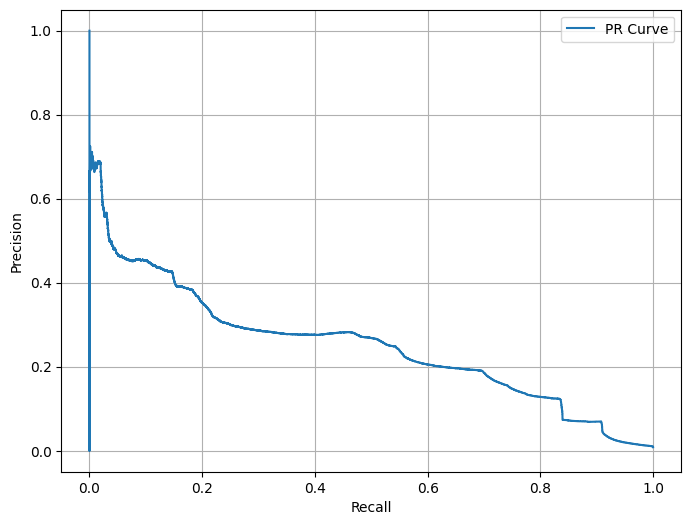

In [ ]:
auc_roc = roc_auc_score(y_val_top, y_pred_top)
auc_pr = average_precision_score(y_val_top, y_pred_top)
print(f"Test data performance:")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")

precisions, recalls, thresholds = precision_recall_curve(y_val_top, y_pred_top)
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='PR Curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [ ]:
f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1])
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

24015.46499215064


/tmp/ipykernel_59237/2842373482.py:1: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1])


In [ ]:
threshold = optimal_threshold
y_pred_top_binary = (y_pred_top > threshold).astype(int)
print(classification_report(y_val_top, y_pred_top_binary))

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00   2759267
         1.0       0.00      0.00      0.00     23356

    accuracy                           0.99   2782623
   macro avg       0.50      0.50      0.50   2782623
weighted avg       0.98      0.99      0.99   2782623



In [ ]:
threshold = 0.995
y_pred_top_binary = (y_pred_top > threshold).astype(int)
print(classification_report(y_val_top, y_pred_top_binary))

              precision    recall  f1-score   support

         0.0       1.00      0.14      0.24   2759267
         1.0       0.01      1.00      0.02     23356

    accuracy                           0.14   2782623
   macro avg       0.50      0.57      0.13   2782623
weighted avg       0.99      0.14      0.24   2782623



In [ ]:
print(confusion_matrix(y_val_top, y_pred_top_binary))

[[ 373007 2386260]
 [      0   23356]]


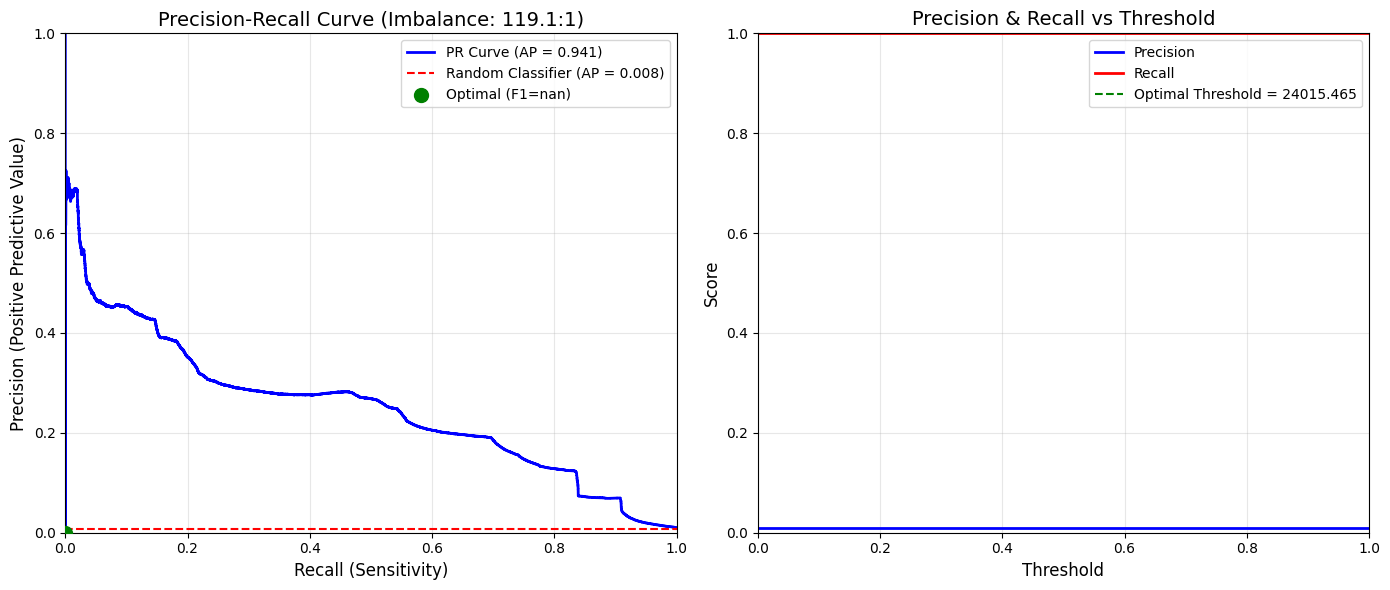

In [ ]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
baseline = y_val_top.mean()
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]
# Plot 1: Precision-Recall Curve
ax1 = axes[0]
ax1.plot(recalls, precisions, 'b-', linewidth=2, label=f'PR Curve (AP = {auc_roc:.3f})')
ax1.axhline(y=baseline, color='r', linestyle='--', label=f'Random Classifier (AP = {baseline:.3f})')
ax1.scatter(optimal_recall, optimal_precision, color='green', s=100,
            zorder=5, label=f'Optimal (F1={optimal_f1:.3f})')
ax1.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax1.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax1.set_title(f'Precision-Recall Curve (Imbalance: {1/baseline:.1f}:1)', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Plot 2: Precision and Recall vs Threshold
ax2 = axes[1]
ax2.plot(thresholds, precisions[:-1], 'b-', linewidth=2, label='Precision')
ax2.plot(thresholds, recalls[:-1], 'r-', linewidth=2, label='Recall')
ax2.axvline(x=optimal_threshold, color='green', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Precision & Recall vs Threshold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

n_products = 24
n_customers = len(y_pred) // n_products

hits = 0
positive_customers = 0

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]
    # skip customers with no positive product
    if true_labels.sum() == 0:
        continue

    positive_customers += 1

    top3_idx = np.argsort(-pred_probs)[:3]

    if true_labels[top3_idx].sum() > 0:
        hits += true_labels[top3_idx].sum()

recall_at_3 = hits / positive_customers

print("Recall@3:", recall_at_3)

Recall@3: 0.7124883664816793


In [ ]:
def average_precision_at_k(y_true, y_score, k=3):

    topk_idx = np.argsort(-y_score)[:k]

    y_true_topk = y_true[topk_idx]

    precisions = []
    num_hits = 0

    for i, rel in enumerate(y_true_topk, start=1):

        if rel == 1:
            num_hits += 1
            precisions.append(num_hits / i)

    if len(precisions) == 0:
        return 0.0

    return np.mean(precisions)


n_products = 24
n_customers = len(y_pred) // n_products

ap_scores = []

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]

    # optional: skip customers without positives
    if true_labels.sum() == 0:
        continue

    ap = average_precision_at_k(true_labels, pred_probs, k=3)

    ap_scores.append(ap)

map_at_3 = np.mean(ap_scores)

print("MAP@3:", map_at_3)

MAP@3: 0.50851688440017


In [ ]:
import numpy as np

n_products = 24
n_customers = len(y_pred) // n_products

hits = 0
positive_customers = 0

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]
    # skip customers with no positive product
    if true_labels.sum() == 0:
        continue

    positive_customers += 1

    top3_idx = np.argsort(-pred_probs)[:3]

    if true_labels[top3_idx].sum() > 0:
        hits += 1

hit_rate_at_3 = hits / positive_customers

print("HitRate@3:", hit_rate_at_3)

HitRate@3: 0.6731584571369481


In [ ]:
import os
y_pred = []
y_val = []
best_best_sgd_path = "/content/drive/My Drive/bank_data/best_best_sgd.pkl"
best_model = joblib.load(best_best_sgd_path)
binary_test_dataset = "/content/drive/My Drive/bank_data/binary_test_dataset/file_1/"
for filepath in os.listdir(binary_test_dataset):
  X_vals, y_vals = generate_dtrain(binary_test_dataset+filepath)
  print(X_vals.isnull().sum().sum())
  X_vals = X_vals.dropna()
  y_preds = best_model.decision_function(X_vals)
  y_pred.extend(y_preds)
  y_val.extend(y_vals)
  del X_vals


0
0
0
24
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [ ]:
y_pred = np.array(y_pred)
y_val = np.array(y_val)

In [ ]:
print(len(y_pred))
print(y_val.sum())
n_customer = len(y_pred) / 24
idx_list = []
for i in range(int(n_customer)):
  start = i*24
  end = start+24
  customer_probs = y_pred[start:end]
  top_probs_idx = np.argsort(-customer_probs)[:6]
  top_probs_idx = top_probs_idx + start
  idx_list.extend(top_probs_idx)
y_val_top = y_val[idx_list]
y_pred_top = y_pred[idx_list]

22350768
31002.0


In [ ]:
print(len(y_val_top))
print(len(y_pred_top))
print(y_val_top.sum() / y_val.sum())

5587692
5587692
0.35910586413779755


Test data performance:
AUC-ROC: 0.7994
AUC-PR: 0.0369


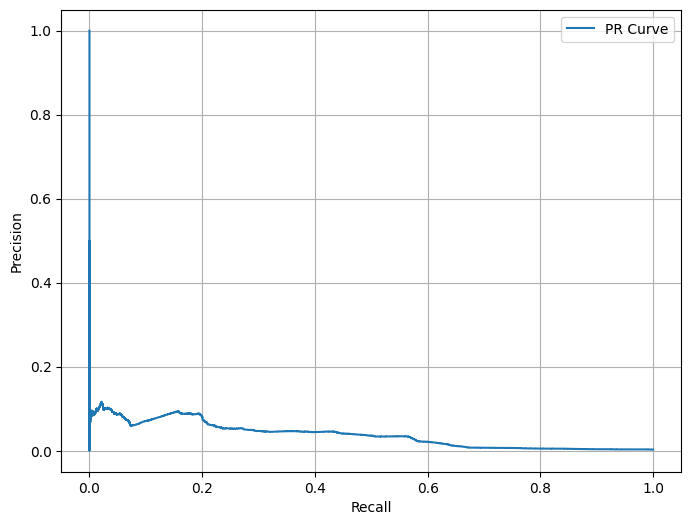

In [ ]:
auc_roc = roc_auc_score(y_val_top, y_pred_top)
auc_pr = average_precision_score(y_val_top, y_pred_top)
print(f"Test data performance:")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")

precisions, recalls, thresholds = precision_recall_curve(y_val_top, y_pred_top)
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='PR Curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [ ]:
f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1])
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

12.98477735542296


/tmp/ipykernel_4507/2842373482.py:1: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1])


In [ ]:
threshold = optimal_threshold
y_pred_top_binary = (y_pred_top > threshold).astype(int)
print(classification_report(y_val_top, y_pred_top_binary))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   2785979
         1.0       0.00      0.00      0.00      7867

    accuracy                           1.00   2793846
   macro avg       0.50      0.50      0.50   2793846
weighted avg       0.99      1.00      1.00   2793846



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
threshold = 0.995
y_pred_top_binary = (y_pred_top > threshold).astype(int)
print(classification_report(y_val_top, y_pred_top_binary))

              precision    recall  f1-score   support

         0.0       1.00      0.11      0.21   2785979
         1.0       0.00      0.99      0.01      7867

    accuracy                           0.12   2793846
   macro avg       0.50      0.55      0.11   2793846
weighted avg       1.00      0.12      0.20   2793846



In [ ]:
print(confusion_matrix(y_val_top, y_pred_top_binary))

[[2785979       0]
 [   7867       0]]


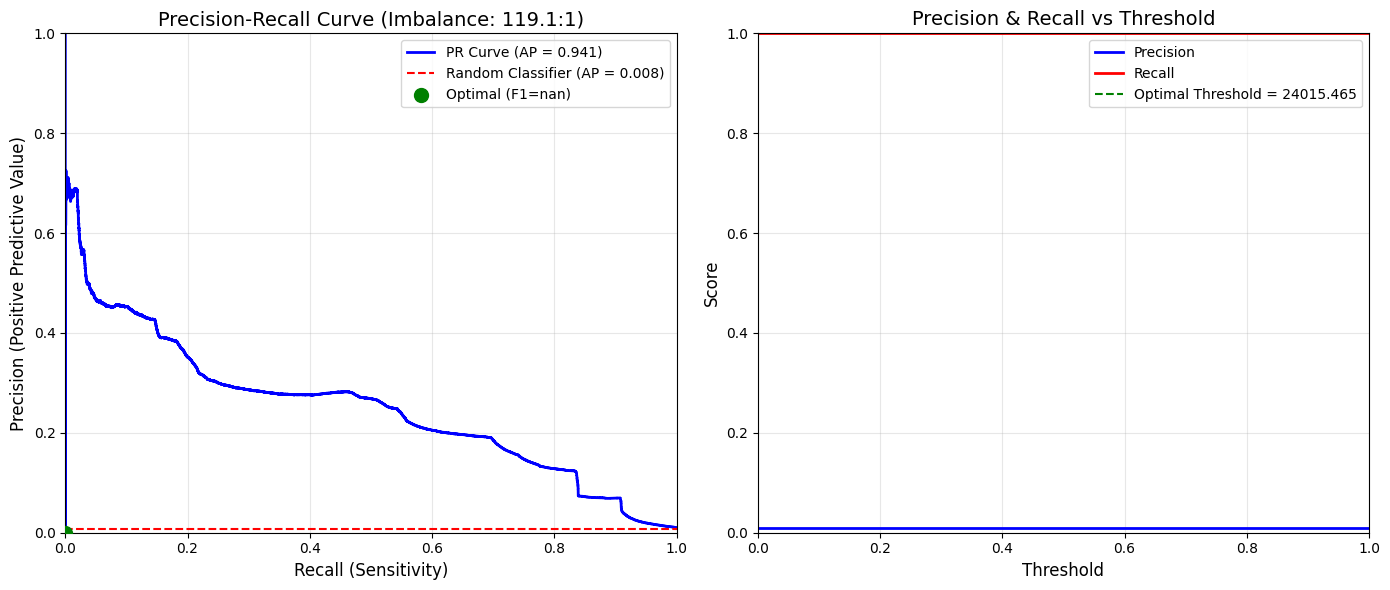

In [ ]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
baseline = y_val_top.mean()
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]
# Plot 1: Precision-Recall Curve
ax1 = axes[0]
ax1.plot(recalls, precisions, 'b-', linewidth=2, label=f'PR Curve (AP = {auc_roc:.3f})')
ax1.axhline(y=baseline, color='r', linestyle='--', label=f'Random Classifier (AP = {baseline:.3f})')
ax1.scatter(optimal_recall, optimal_precision, color='green', s=100,
            zorder=5, label=f'Optimal (F1={optimal_f1:.3f})')
ax1.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax1.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax1.set_title(f'Precision-Recall Curve (Imbalance: {1/baseline:.1f}:1)', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Plot 2: Precision and Recall vs Threshold
ax2 = axes[1]
ax2.plot(thresholds, precisions[:-1], 'b-', linewidth=2, label='Precision')
ax2.plot(thresholds, recalls[:-1], 'r-', linewidth=2, label='Recall')
ax2.axvline(x=optimal_threshold, color='green', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Precision & Recall vs Threshold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

n_products = 24
n_customers = len(y_pred) // n_products

hits = 0
positive_customers = 0

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]
    # skip customers with no positive product
    if true_labels.sum() == 0:
        continue

    positive_customers += 1

    top3_idx = np.argsort(-pred_probs)[:6]

    if true_labels[top3_idx].sum() > 0:
        hits += true_labels[top3_idx].sum()

recall_at_3 = hits / positive_customers

print("Recall@3:", recall_at_3)

Recall@3: 0.3969974681738758


In [ ]:
def average_precision_at_k(y_true, y_score, k=3):

    topk_idx = np.argsort(-y_score)[:k]

    y_true_topk = y_true[topk_idx]

    precisions = []
    num_hits = 0

    for i, rel in enumerate(y_true_topk, start=1):

        if rel == 1:
            num_hits += 1
            precisions.append(num_hits / i)

    if len(precisions) == 0:
        return 0.0

    return np.mean(precisions)


n_products = 24
n_customers = len(y_pred) // n_products

ap_scores = []

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]

    # optional: skip customers without positives
    if true_labels.sum() == 0:
        continue

    ap = average_precision_at_k(true_labels, pred_probs, k=6)

    ap_scores.append(ap)

map_at_3 = np.mean(ap_scores)

print("MAP@3:", map_at_3)

MAP@3: 0.1660957279891595


In [ ]:
import numpy as np

n_products = 24
n_customers = len(y_pred) // n_products

hits = 0
positive_customers = 0

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]
    # skip customers with no positive product
    if true_labels.sum() == 0:
        continue

    positive_customers += 1

    top3_idx = np.argsort(-pred_probs)[:6]

    if true_labels[top3_idx].sum() > 0:
        hits += 1

hit_rate_at_3 = hits / positive_customers

print("HitRate@3:", hit_rate_at_3)

HitRate@3: 0.37920336625895945
